<a href="https://colab.research.google.com/github/hasselmanneduarda-wq/bioestat-2026/blob/main/Tarefa_11.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##Tarefa 11
###André Luiz Leal (16854274)
###Maria Eduarda Hasselmann(17100517)
###Raissa Lara Pinheiro (16939302)


# Módulo de bioestatística: variáveis aleatórias e modelo de Bernoulli

> **Natureza dos dados:** os exemplos deste notebook utilizam dados simulados para fins didáticos. Os parâmetros adotados representam cenários biologicamente plausíveis e são utilizados para demonstrar o funcionamento dos modelos probabilísticos.

## 1. Definição de variável aleatória em contexto biológico

Uma **variável aleatória (V.A.)** é uma função matemática que associa um número real a cada resultado possível de um experimento aleatório. Em Biologia, um experimento é considerado aleatório quando seu resultado não pode ser previsto com certeza absoluta antes da execução, devido à variabilidade biológica intrínseca ou ao acaso.

**Exemplo biológico: germinação de uma semente**
- **Experimento aleatório:** observar uma semente após 14 dias sob condições controladas.
- **Variável aleatória (X):** estado de germinação da semente.
- **Valores possíveis:** X = 1, se a semente germinar; X = 0, se não germinar.

## 2. Variáveis aleatórias discretas vs. contínuas

A classificação de uma variável aleatória depende da natureza do seu conjunto de valores possíveis:

- **Variável aleatória discreta:** assume um conjunto de valores finito ou infinito enumerável, geralmente associado a contagens.
- **Variável aleatória contínua:** pode assumir qualquer valor dentro de um intervalo contínuo, geralmente associado a medições.

## 3. Exemplos biológicos com justificativas

### Variáveis discretas
1. **Número de filhotes por ninhada de uma espécie de mamífero:** assume valores inteiros não negativos; não é possível observar 2,5 filhotes.
2. **Quantidade de colônias bacterianas (UFC) em uma placa de Petri:** resulta de uma contagem expressa em números inteiros.
3. **Número de indivíduos de uma espécie vegetal parasitados por um fungo em um transecto:** corresponde à contagem de indivíduos afetados.

### Variáveis contínuas
1. **Massa corporal (g) de pequenos roedores:** pode assumir valores decimais dentro de um intervalo, de acordo com a precisão da balança.
2. **Comprimento da lâmina foliar (cm):** é obtido por medição e pode assumir valores decimais.
3. **Concentração de oxigênio dissolvido (mg/L) em água:** pode variar continuamente dentro da escala de medição.


## 4. O Modelo teórico de Bernoulli

O **Ensaio de Bernoulli** é um modelo probabilístico discreto aplicado a um experimento aleatório que possui apenas dois resultados possíveis e mutuamente exclusivos, tradicionalmente denominados sucesso e fracasso.

### Componentes do modelo de Bernoulli:
* **Sucesso ($1$):** O evento de interesse biológico que está sendo monitorado.
* **Fracasso ($0$):** O evento complementar ao sucesso.
* **Variável Aleatória de Bernoulli ($X$):** Define-se como:
  $$X = \begin{cases} 1, & \text{se ocorrer o sucesso} \\ 0, & \text{se ocorrer o fracasso} \end{cases}$$
* **Probabilidade de Sucesso ($p$):** A probabilidade teórica atribuída à ocorrência do evento de interesse, onde $P(X = 1) = p$.
* **Probabilidade de Fracasso ($q$):** A probabilidade do evento complementar, dada por $q = 1 - p$, de modo que $P(X = 0) = 1 - p$.


## 5. Exemplo aplicado: germinação de sementes

Consideremos um experimento agronômico avaliando a capacidade germinativa de sementes da espécie *Paspalum notatum* sob condições estipuladas.

* **Experimento:** Observar o estado de uma semente individual após 14 dias de incubação.
* **Sucesso ($X = 1$):** A semente germinou.
* **Fracasso ($X = 0$):** A semente não germinou (permaneceu dormente ou inviável).
* **Probabilidade de Sucesso ($p$):** Assumindo que a taxa histórica/teórica de germinação desse lote é de $75\%$, temos $p = 0,75$ e $1 - p = 0,25$.

--- RESULTADOS DA SIMULAÇÃO DE BERNOULLI ---
    Resultado Biológico  Variável Aleatória (X)  Frequência Absoluta  Proporção Observada  Probabilidade Teórica (p)
Não Germinou (Fracasso)                       0                  243                0.243                       0.25
     Germinou (Sucesso)                       1                  757                0.757                       0.75


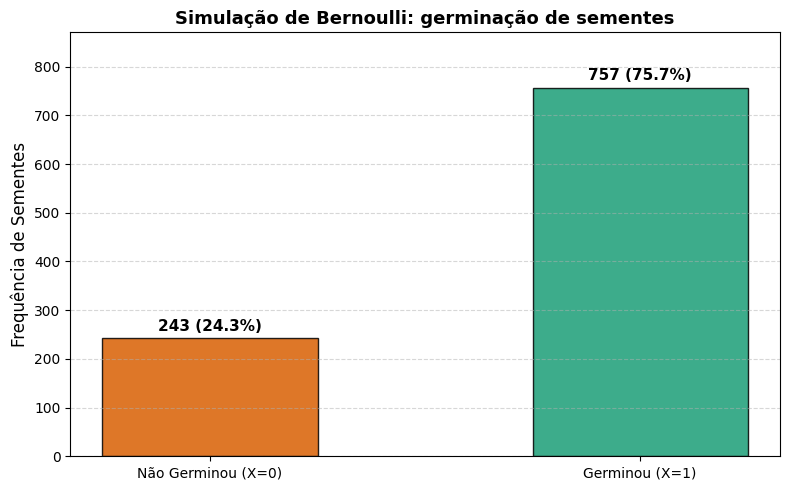

In [ ]:

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# 1. Configuração dos parâmetros do experimento biológico
np.random.seed(42)  # Garantir reprodutibilidade dos resultados
p_sucesso = 0.75    # Probabilidade teórica de germinação (75%)
n_simulacoes = 1000 # Número de sementes individuais testadas na simulação

# 2. Execução da simulação de Bernoulli (0 = Não germinou, 1 = Germinou)
resultados = np.random.binomial(n=1, p=p_sucesso, size=n_simulacoes)

# 3. Processamento estatístico dos dados gerados
contagem_fracassos = np.sum(resultados == 0)
contagem_sucessos = np.sum(resultados == 1)

prop_fracassos = contagem_fracassos / n_simulacoes
prop_sucessos = contagem_sucessos / n_simulacoes

# Criando um DataFrame para exibição estruturada
df_resultados = pd.DataFrame({
    'Resultado Biológico': ['Não Germinou (Fracasso)', 'Germinou (Sucesso)'],
    'Variável Aleatória (X)': [0, 1],
    'Frequência Absoluta': [contagem_fracassos, contagem_sucessos],
    'Proporção Observada': [prop_fracassos, prop_sucessos],
    'Probabilidade Teórica (p)': [1 - p_sucesso, p_sucesso]
})

print("--- RESULTADOS DA SIMULAÇÃO DE BERNOULLI ---")
print(df_resultados.to_string(index=False))

# 4. Visualização Gráfica
fig, ax = plt.subplots(figsize=(8, 5))
categorias = ['Não Germinou (X=0)', 'Germinou (X=1)']
frequencias = [contagem_fracassos, contagem_sucessos]
cores = ['#d95f02', '#1b9e77']

bars = ax.bar(categorias, frequencias, color=cores, width=0.5, edgecolor='black', alpha=0.85)

# Adicionar rótulos nas barras
for bar in bars:
    height = bar.get_height()
    ax.annotate(f'{height} ({height/n_simulacoes:.1%})',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3),
                textcoords="offset points",
                ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.set_ylabel('Frequência de Sementes', fontsize=12)
ax.set_title('Simulação de Bernoulli: germinação de sementes', fontsize=13, fontweight='bold')
ax.set_ylim(0, max(frequencias) * 1.15)
ax.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

##6. Análise dos resultados

A partir da simulação realizada com 1.000 sementes, considerando uma probabilidade de germinação de 75%, foi possível observar que a proporção de sementes germinadas tende a se aproximar desse valor esperado. Esse resultado está relacionado à Lei dos Grandes Números, que explica que quanto maior o número de repetições de um experimento, maior a tendência de a frequência observada se aproximar da probabilidade teórica. Nesse caso, o modelo de Bernoulli permite representar a germinação das sementes considerando dois resultados possíveis, a semente germina ou não germina.

Do ponto de vista biológico esse modelo pode ser utilizado para estudar situações como a germinação de sementes, a sobrevivência de plantas e a presença de determinadas características nos organismos. Apesar de não ser possível prever com certeza se uma única semente irá germinar, a probabilidade ajuda a entender quantas sementes podem germinar em um grupo maior, sendo útil em experimentos de laboratório e em atividades agrícolas. No entanto, é importante lembrar que fatores como a temperatura, a disponibilidade de água e a qualidade das sementes podem influenciar a germinação e nos resultados observados.

### Conclusão

O modelo de Bernoulli é adequado para representar a resposta de **uma única semente**, pois existem apenas dois resultados possíveis: germinar ou não germinar. Na simulação, a frequência de germinação se aproxima da probabilidade teórica de 75% à medida que aumenta o número de observações.


# Distribuição Binomial

###1. O que é:

A **Distribuição Binomial** é um tipo de distribuição de probabilidade discreta aplicada em casos de experimentos repetidos, onde existem dois possíveis resultados. A importância da distribuição binomial na estatística vem de sua capacidade de modelar situações reais em que nos interessa a frequência com que um evento específico ocorre dentro de um número definido de tentativas.

###Assim, uma variável aleatória poderá ter sua distribuição de probabilidade modelada de forma binomial caso atenda os seguintes pressupostos:

- Resultados binários por tentativa

- Número fixo de tentativas ($n$)

- Tentativas independentes

- Probabilidade constante de "sucesso" ($p$) em cada tentativa


###2. Fórmula da Probabilidade Binomial

A probabilidade de obter exatamente $k$ sucessos em $n$ ensaios é dada pela fórmula:

$$P(X=k) = \binom{n}{k} p^k (1-p)^{n-k}$$

Onde:
- $P(X=k)$ é a probabilidade de $k$ sucessos.
- $\binom{n}{k}$ é o coeficiente binomial, lido como "$n$ escolhe $k$", e é calculado como $\frac{n!}{k!(n-k)!}$.
- $n$ é o número total de ensaios.
- $k$ é o número de sucessos desejados.
- $p$ é a probabilidade de sucesso em um único ensaio.
- $(1-p)$ é a probabilidade de fracasso em um único ensaio.

###3. Exemplo Biológico: Germinação de Sementes

Vamos considerar um experimento onde plantamos $n$ sementes e queremos observar quantas delas germinam. Suponha que a probabilidade de uma única semente germinar seja $p$.

Neste cenário:
- **Número fixo de ensaios ($n$)**: O número total de sementes plantadas.
- **Dois resultados possíveis**: Uma semente pode germinar (sucesso) ou não germinar (fracasso).
- **Probabilidade de sucesso constante ($p$)**: A probabilidade de germinação é a mesma para cada semente.
- **Independência aproximada**: A germinação de uma semente é considerada independente da germinação de outra.

Vamos definir os parâmetros para um exemplo específico:
- **$n$**: Número total de sementes = 10
- **$p$**: Probabilidade de uma semente germinar = 0.7 (70%)
- **Variável Aleatória ($X$)**: O número de sementes que germinam entre as 10 plantadas.

###4. Implementação em Python: Cálculos de Probabilidades

In [ ]:
from scipy.stats import binom
import numpy as np

# Definir os parâmetros
n = 10  # Número total de sementes
p = 0.7 # Probabilidade de germinação de uma semente

# Criar uma variável aleatória binomial
binomial_dist = binom(n, p)

# Calcular a probabilidade de exatamente 7 sementes germinarem (P(X=7))
k_exact = 7
prob_exact = binomial_dist.pmf(k_exact)
print(f"Probabilidade de exatamente {k_exact} sementes germinarem: {prob_exact:.4f}")

# Calcular a probabilidade de no máximo 5 sementes germinarem (P(X <= 5))
k_max = 5
prob_cumulative = binomial_dist.cdf(k_max)
print(f"Probabilidade de no máximo {k_max} sementes germinarem: {prob_cumulative:.4f}")

# Calcular a probabilidade de pelo menos 8 sementes germinarem (P(X >= 8))
k_min = 8
prob_at_least = 1 - binomial_dist.cdf(k_min - 1)
print(f"Probabilidade de pelo menos {k_min} sementes germinarem: {prob_at_least:.4f}")

# Obter as probabilidades para todos os possíveis números de sucessos (0 a n)
k_values = np.arange(0, n + 1)
probabilities = binomial_dist.pmf(k_values)

print("\nProbabilidades para cada número de sementes germinadas:")
for k, prob in zip(k_values, probabilities):
    print(f"P(X={k}) = {prob:.4f}")

Probabilidade de exatamente 7 sementes germinarem: 0.2668
Probabilidade de no máximo 5 sementes germinarem: 0.1503
Probabilidade de pelo menos 8 sementes germinarem: 0.3828

Probabilidades para cada número de sementes germinadas:
P(X=0) = 0.0000
P(X=1) = 0.0001
P(X=2) = 0.0014
P(X=3) = 0.0090
P(X=4) = 0.0368
P(X=5) = 0.1029
P(X=6) = 0.2001
P(X=7) = 0.2668
P(X=8) = 0.2335
P(X=9) = 0.1211
P(X=10) = 0.0282


###5. Visualização da Distribuição de Probabilidades

/tmp/ipykernel_6158/3167673132.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=k_values, y=probabilities, palette='viridis')


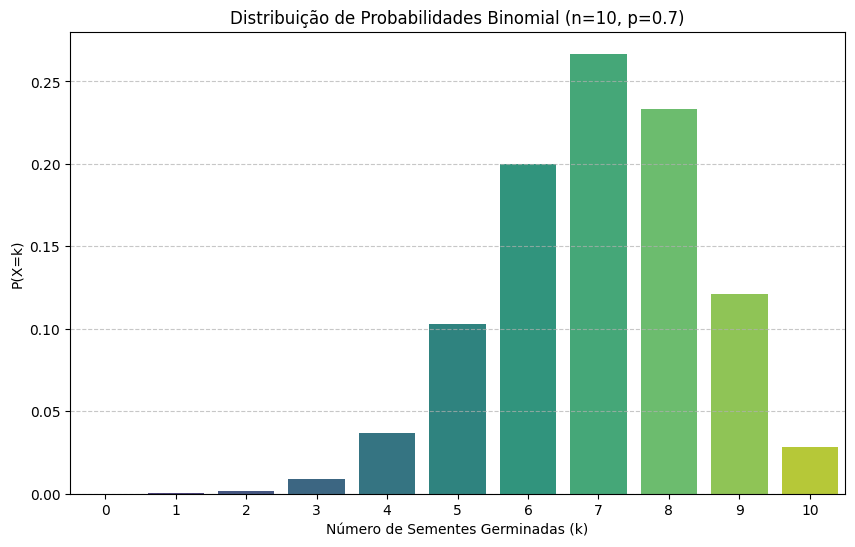

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Certifique-se de que k_values e probabilities estão definidos do código anterior
# Caso contrário, defina-os novamente:
# n = 10
# p = 0.7
# binomial_dist = binom(n, p)
# k_values = np.arange(0, n + 1)
# probabilities = binomial_dist.pmf(k_values)

plt.figure(figsize=(10, 6))
sns.barplot(x=k_values, y=probabilities, palette='viridis')
plt.title('Distribuição de Probabilidades Binomial (n=10, p=0.7)')
plt.xlabel('Número de Sementes Germinadas (k)')
plt.ylabel('P(X=k)')
plt.xticks(k_values) # Garante que todos os valores de k são exibidos no eixo x
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

###6. Interpretação dos Resultados

Com base nos cálculos e no gráfico de barras, podemos interpretar os resultados da seguinte forma:

1.  **Probabilidades Individuais (P(X=k))**:
    *   `P(X=0) = 0.0000`, `P(X=1) = 0.0001`, `P(X=2) = 0.0014`, `P(X=3) = 0.0090`, `P(X=4) = 0.0368`, `P(X=5) = 0.1029`, `P(X=6) = 0.2001`, `P(X=7) = 0.2668`, `P(X=8) = 0.2335`, `P(X=9) = 0.1211`, `P(X=10) = 0.0282`.
    *   Esses valores representam a probabilidade exata de que um determinado número de sementes (k) germine em 10 tentativas. Por exemplo, a probabilidade de exatamente 7 sementes germinarem é de 26.68%.

2.  **Probabilidades Acumuladas**:
    *   `Probabilidade de no máximo 5 sementes germinarem: 0.1503` (P(X <= 5)): Isso significa que há uma chance de 15.03% de que 5 ou menos sementes germinem. Este é o somatório das probabilidades de 0 a 5 sucessos.
    *   `Probabilidade de pelo menos 8 sementes germinarem: 0.3828` (P(X >= 8)): Isso indica que há uma chance de 38.28% de que 8 ou mais sementes germinem. Este é o somatório das probabilidades de 8, 9 e 10 sucessos.

3.  **Gráfico de Barras**:
    *   O gráfico visualiza a distribuição de probabilidades, mostrando claramente que as probabilidades são mais altas para $k$ em torno de 7, o que faz sentido, já que a probabilidade de sucesso ($p$) é 0.7. O pico da distribuição ocorre no valor esperado (n*p = 10*0.7 = 7), ou próximo a ele.
    *   As barras demonstram como a probabilidade diminui à medida que nos afastamos do valor esperado, tanto para números muito baixos quanto para números muito altos de sementes germinadas.

Em resumo, a distribuição binomial nos permite quantificar a probabilidade de obter um certo número de 'sucessos' (sementes germinadas) em um número fixo de 'tentativas' (sementes plantadas), considerando uma probabilidade constante de sucesso para cada tentativa.

###7. Limitações das Suposições e Discussão

Embora a distribuição binomial seja uma ferramenta poderosa, é crucial reconhecer as limitações de suas suposições, especialmente quando aplicada a cenários reais, como o da germinação de sementes:

1.  **Independência dos Ensaios**: A suposição de que cada semente germina independentemente das outras pode não ser totalmente verdadeira. Fatores como condições do solo (nutrientes, umidade), pragas, ou doenças podem afetar múltiplas sementes de forma correlacionada. Por exemplo, se há um fungo no solo, a probabilidade de germinação de sementes próximas pode ser reduzida, violando a independência.

2.  **Probabilidade de Sucesso Constante ($p$)**: Assumimos que a probabilidade de germinação ($p=0.7$) é a mesma para todas as sementes. Na realidade, esta probabilidade pode variar devido a:
    *   **Variação Genética**: Algumas sementes podem ter maior viabilidade que outras.
    *   **Condições Microambientais**: Diferenças sutis na profundidade de plantio, exposição à luz, ou contato com a água podem alterar a probabilidade de germinação para sementes individuais.
    *   **Envelhecimento da Semente**: Se as sementes não são da mesma idade ou foram armazenadas sob condições diferentes, suas probabilidades de germinação podem variar.

3.  **Dois Resultados Possíveis**: Embora 'germinar' e 'não germinar' sejam resultados claros, a realidade pode ser mais complexa. Por exemplo, uma semente pode começar a germinar mas morrer antes de emergir, ou pode haver um estado intermediário difícil de categorizar. Para os propósitos da binomial, simplificamos para apenas dois resultados mutuamente exclusivos.

4.  **Número Fixo de Ensaios**: Esta suposição é geralmente robusta, pois o número de sementes plantadas é uma quantidade que podemos controlar e fixar. No entanto, é importante garantir que *todas* as sementes sejam consideradas nos ensaios e que nenhuma seja perdida ou removida acidentalmente.

**Impacto das Limitações**:

A violação dessas suposições pode levar a um modelo binomial que superestima ou subestima a probabilidade de certos resultados. Por exemplo, se a independência for violada por um fator ambiental que afeta todas as sementes, a variabilidade observada pode ser diferente daquela prevista pela distribuição binomial. No entanto, para muitas aplicações práticas, a distribuição binomial serve como uma boa aproximação inicial e um modelo base para entender o fenômeno.

### Conclusão

A distribuição Binomial é adequada para representar o **número de sementes germinadas em um número fixo de sementes**, desde que a probabilidade de germinação seja aproximadamente constante e os ensaios possam ser considerados aproximadamente independentes. No exemplo, o modelo permite calcular e visualizar as probabilidades associadas a diferentes números de sementes germinadas.


# Distribuição de Poisson

A distribuição de Poisson é um modelo probabilístico discreto utilizado para representar a quantidade de vezes que determinado evento ocorre em um intervalo definido de tempo, espaço, área, volume ou outra unidade de observação.

Diferentemente da distribuição Binomial, a Poisson não exige um número fixo de tentativas. Seu objetivo é modelar contagens de ocorrências a partir de uma **taxa média**.

Sua função de probabilidade é:

$$
P(X=k)=\frac{e^{-\lambda}\lambda^k}{k!}
$$

Em que:
- $P(X=k)$: probabilidade de ocorrerem exatamente $k$ eventos;
- $\lambda$: número médio esperado de ocorrências na unidade de observação;
- $k$: número de eventos observados (0, 1, 2, 3, ...);
- $e$: constante matemática aproximadamente igual a 2,71828;
- $k!$: fatorial de $k$.

Na distribuição de Poisson:

$$
E(X)=Var(X)=\lambda
$$

## 1. Parâmetro $\lambda$ e unidade de observação

O parâmetro $\lambda$ representa a quantidade média esperada de eventos na unidade de observação escolhida.

## 2. Exemplo biológico: captura de insetos

Considere um cenário hipotético de monitoramento entomológico no qual uma armadilha captura, em média, **4 insetos por noite**.

**Identificação do experimento**
- **Experimento aleatório:** observar uma armadilha durante uma noite de monitoramento.
- **Variável aleatória (X):** número de insetos capturados.
- **Valores possíveis:** 0, 1, 2, 3, ... insetos.
- **Unidade de observação:** uma armadilha durante uma noite.
- **Taxa média:** $\lambda = 4$ insetos/armadilha/noite.
- **Número de observações simuladas:** 1.000 noites.

> **Dados simulados:** o valor $\lambda=4$ foi adotado apenas para fins didáticos, representando um cenário biologicamente plausível de monitoramento. Não corresponde a um conjunto de dados reais.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.stats import poisson

# Parâmetros do cenário biológico simulado
np.random.seed(42)
lambda_medio = 4       # insetos por armadilha por noite
n_simulacoes = 1000    # número de noites simuladas

print("--- PARÂMETROS DO EXPERIMENTO ---")
print("Unidade de observação: uma armadilha durante uma noite")
print(f"Taxa média (λ): {lambda_medio} insetos/armadilha/noite")
print(f"Número de noites simuladas: {n_simulacoes}")


--- PARÂMETROS DO EXPERIMENTO ---
Unidade de observação: uma armadilha durante uma noite
Taxa média (λ): 4 insetos/armadilha/noite
Número de noites simuladas: 1000


### 3. Cálculo das probabilidades

Considerando uma taxa média de **4 insetos por armadilha/noite**, calcularemos as probabilidades de diferentes números de capturas.

A função `poisson.pmf()` calcula a probabilidade de ocorrer exatamente determinada quantidade de eventos.

Serão analisadas três situações:
- probabilidade de capturar exatamente 4 insetos;
- probabilidade de capturar menos de 3 insetos;
- probabilidade de capturar pelo menos 6 insetos.

A tabela apresenta a distribuição teórica para contagens de 0 a 15 insetos por armadilha/noite.


In [ ]:
# Distribuição teórica de Poisson
quantidades = np.arange(0, 16)
probabilidades = poisson.pmf(quantidades, mu=lambda_medio)

df_poisson = pd.DataFrame({
    'Insetos Capturados (X)': quantidades,
    'Probabilidade Teórica': probabilidades,
    'Probabilidade (%)': probabilidades * 100
})

print("DISTRIBUIÇÃO TEÓRICA DE POISSON")
display(df_poisson.round(4))

# Probabilidades específicas
p_4 = poisson.pmf(4, lambda_medio)
p_menos_3 = poisson.cdf(2, lambda_medio)
p_pelo_menos_6 = poisson.sf(5, lambda_medio)

print("\nPROBABILIDADES ESPECÍFICAS")
print(f"P(X = 4): {p_4:.4f}")
print(f"P(X < 3): {p_menos_3:.4f}")
print(f"P(X >= 6): {p_pelo_menos_6:.4f}")


DISTRIBUIÇÃO TEÓRICA DE POISSON


,Insetos Capturados (X),Probabilidade Teórica,Probabilidade (%)
0,0,0.0183,1.8316
1,1,0.0733,7.3263
2,2,0.1465,14.6525
3,3,0.1954,19.5367
4,4,0.1954,19.5367
5,5,0.1563,15.6293
6,6,0.1042,10.4196
7,7,0.0595,5.9540
8,8,0.0298,2.9770
9,9,0.0132,1.3231



PROBABILIDADES ESPECÍFICAS
P(X = 4): 0.1954
P(X < 3): 0.2381
P(X >= 6): 0.2149


### 4. Representação gráfica da distribuição

O gráfico apresenta as probabilidades teóricas da distribuição de Poisson para uma média de **4 insetos capturados por armadilha/noite**.

O eixo horizontal representa o número de insetos capturados e o eixo vertical representa a probabilidade associada a cada contagem. As maiores probabilidades tendem a se concentrar próximas à taxa média adotada.


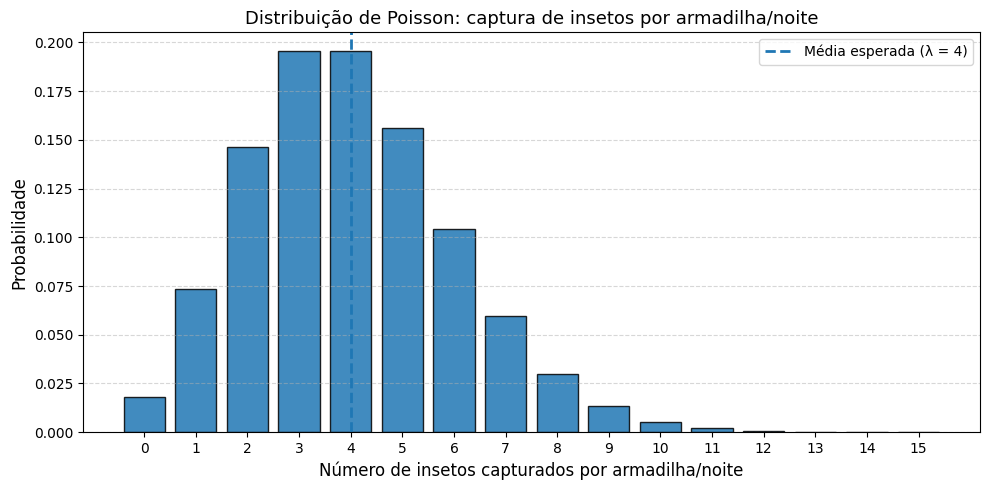

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.bar(quantidades, probabilidades, edgecolor='black', alpha=0.85)
ax.axvline(
    lambda_medio,
    linestyle='--',
    linewidth=2,
    label=f'Média esperada (λ = {lambda_medio})'
)

ax.set_xlabel('Número de insetos capturados por armadilha/noite', fontsize=12)
ax.set_ylabel('Probabilidade', fontsize=12)
ax.set_title('Distribuição de Poisson: captura de insetos por armadilha/noite', fontsize=13)
ax.set_xticks(quantidades)
ax.grid(axis='y', linestyle='--', alpha=0.5)
ax.legend()

plt.tight_layout()
plt.show()


### 5. Simulação computacional

Para complementar os cálculos teóricos, serão simuladas **1.000 noites de monitoramento** utilizando uma distribuição de Poisson com $\lambda=4$.

Cada observação representa o número hipotético de insetos capturados por uma armadilha durante uma noite. A semente aleatória foi fixada em 42 para tornar a simulação reprodutível.


In [ ]:
# Simulação de 1.000 noites
resultados_poisson = np.random.poisson(
    lam=lambda_medio,
    size=n_simulacoes
)

media_simulada = np.mean(resultados_poisson)
variancia_simulada = np.var(resultados_poisson, ddof=1)

valores, frequencias = np.unique(resultados_poisson, return_counts=True)

df_resultados = pd.DataFrame({
    'Insetos Capturados (X)': valores,
    'Frequência Absoluta': frequencias,
    'Proporção Observada': frequencias / n_simulacoes,
    'Probabilidade Teórica': poisson.pmf(valores, lambda_medio)
})

print("RESULTADOS DA SIMULAÇÃO DE POISSON")
print(df_resultados.to_string(index=False))

print("\nESTATÍSTICAS")
print(f"Média teórica: {lambda_medio:.2f}")
print(f"Média simulada: {media_simulada:.2f}")
print(f"Variância teórica: {lambda_medio:.2f}")
print(f"Variância simulada: {variancia_simulada:.2f}")


RESULTADOS DA SIMULAÇÃO DE POISSON
 Insetos Capturados (X)  Frequência Absoluta  Proporção Observada  Probabilidade Teórica
                      0                   27                0.027               0.018316
                      1                   80                0.080               0.073263
                      2                  136                0.136               0.146525
                      3                  199                0.199               0.195367
                      4                  197                0.197               0.195367
                      5                  161                0.161               0.156293
                      6                   89                0.089               0.104196
                      7                   66                0.066               0.059540
                      8                   25                0.025               0.029770
                      9                   15                0.015          

### 6. Comparação entre distribuição teórica e simulação

O gráfico compara as frequências relativas observadas nas 1.000 noites simuladas com as probabilidades previstas pela distribuição teórica de Poisson.

Como os dados foram gerados pelo próprio modelo, espera-se que as frequências simuladas se aproximem das probabilidades teóricas, com pequenas diferenças decorrentes da aleatoriedade.


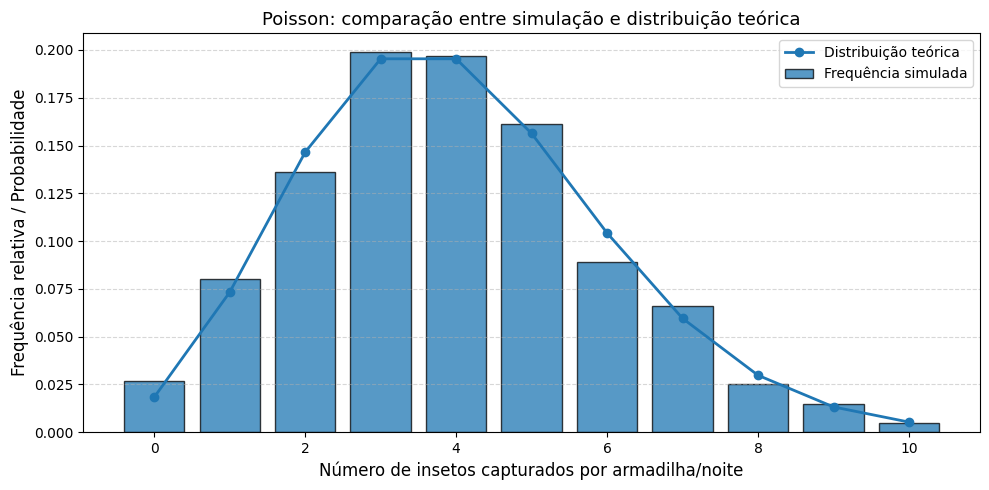

In [ ]:
valores_grafico = np.arange(0, resultados_poisson.max() + 1)

freq_simulada = np.bincount(
    resultados_poisson,
    minlength=len(valores_grafico)
)[:len(valores_grafico)] / n_simulacoes

prob_teorica = poisson.pmf(valores_grafico, lambda_medio)

fig, ax = plt.subplots(figsize=(10, 5))

ax.bar(
    valores_grafico,
    freq_simulada,
    alpha=0.75,
    edgecolor='black',
    label='Frequência simulada'
)

ax.plot(
    valores_grafico,
    prob_teorica,
    'o-',
    linewidth=2,
    label='Distribuição teórica'
)

ax.set_xlabel('Número de insetos capturados por armadilha/noite', fontsize=12)
ax.set_ylabel('Frequência relativa / Probabilidade', fontsize=12)
ax.set_title('Poisson: comparação entre simulação e distribuição teórica', fontsize=13)
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()


### 7. Interpretação dos resultados e limitações

Com uma taxa média de $\lambda=4$ insetos por armadilha/noite, a distribuição de Poisson permite calcular as probabilidades associadas a diferentes números de capturas. Na simulação de 1.000 noites, a média e a variância simuladas tendem a ficar próximas do valor teórico 4.

Biologicamente, o modelo pode ser útil para representar contagens de insetos quando as ocorrências são aproximadamente independentes e a taxa média se mantém relativamente constante na unidade de observação.

Entretanto, essas condições podem não ser totalmente satisfeitas em monitoramentos reais. Temperatura, chuva, vento, disponibilidade de alimento, densidade populacional e eficiência da armadilha podem alterar a taxa de captura entre noites. Além disso, agregação de insetos ou dependência entre ocorrências pode produzir uma variabilidade diferente daquela prevista pela distribuição de Poisson.

### Conclusão

A distribuição de Poisson é adequada para representar **contagens de eventos em uma unidade definida**, como o número de insetos capturados por uma armadilha durante uma noite. No cenário simulado, $\lambda=4$ representa a taxa média de captura e permite calcular e simular as probabilidades de diferentes números de insetos observados.


### 8. Comparação entre Bernoulli, Binomial e Poisson

Os três modelos representam variáveis aleatórias discretas, mas descrevem fenômenos diferentes.

| Característica | Bernoulli | Binomial | Poisson |
|---|---|---|---|
| Fenômeno | Resultado de um único ensaio | Número de sucessos em um conjunto fixo de ensaios | Número de ocorrências em uma unidade definida |
| Valores possíveis | 0 ou 1 | 0, 1, 2, ..., n | 0, 1, 2, 3, ... |
| Parâmetros | p | n e p | λ |
| Média | p | np | λ |
| Variância | p(1-p) | np(1-p) | λ |
| Exemplo biológico | Uma semente germina ou não | Número de sementes germinadas em uma amostra fixa | Número de insetos capturados por armadilha/noite |
| Unidade de observação | Uma semente | Uma amostra com número fixo de sementes | Uma armadilha durante uma noite |
| Aplicação | Um resultado classificado como sucesso ou fracasso | Contagem de sucessos em número fixo de tentativas | Contagem de eventos por tempo, área, volume ou outra unidade |
| Limitação principal | Representa apenas um ensaio | Exige número fixo de ensaios e probabilidade aproximadamente constante | Pressupõe taxa média relativamente constante e ocorrências aproximadamente independentes |

### Considerações finais

Os modelos de Bernoulli, Binomial e Poisson permitem representar diferentes situações probabilísticas aplicadas à Biologia. Bernoulli descreve um único evento com dois resultados possíveis, enquanto a Binomial representa o número de sucessos em um conjunto fixo de observações. Já a distribuição de Poisson é utilizada para modelar a ocorrência de eventos em uma unidade definida, como o número de insetos capturados por armadilha durante uma noite.
As simulações em Python permitiram comparar os resultados observados com os valores esperados e compreender o comportamento de cada distribuição. Assim, a escolha do modelo deve considerar as características do fenômeno biológico e as condições necessárias para sua aplicação.


#REFERÊNCIAS
USSHAB, Wilton de Oliveira; MORETTIN, Pedro Alberto. Estatística básica. 9. ed. São Paulo: Saraiva, 2017.
CALLEGARI-JACQUES, Sidia Maria. Bioestatística: princípios e aplicações. Porto Alegre: Artmed, 2003.
GOTT think, Gotelli, Nicholas J.; ELLISON, Aaron M. Princípios de estatística em ecologia. Porto Alegre: Artmed, 2011.
MAGALHÃES, Marcos Nascimento; LIMA, Antonio Carlos Pedroso de. Noções de probabilidade e estatística. 7. ed. São Paulo: EdUSP, 2015.
TRIOLA, Mario F. Introdução à estatística: atualização da tecnologia. 12. ed. Rio de Janeiro: LTC, 2017.
ZAR, Jerrold H. Biostatistical analysis. 5th ed. Upper Saddle River: Pearson Prentice Hall, 2010.
